In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import torch
import cv2
from ultralytics import YOLO
from sklearn.model_selection import train_test_split
import shutil
from tqdm import tqdm
from pathlib import Path
import albumentations as A

WARNING ⚠️ torchvision==0.19 is incompatible with torch==2.7.
Run 'pip install torchvision==0.22' to fix torchvision or 'pip install -U torch torchvision' to update both.
For a full compatibility table see https://github.com/pytorch/vision#installation


/lustrefs/disk/project/ai901504-ai0004/501641_Big/week5/env_image/lib/python3.10/site-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error [Errno 101] Network is unreachable>
  data = fetch_version_info()


# Data

In [ ]:
train_df = pd.read_csv("/project/ai901504-ai0004/kaggle_competition/week5/liver-fibrosis-severity-prediction/train.csv")
print(train_df)

In [ ]:
train_df['SWE fibrosis stage'] = train_df['SWE fibrosis stage'].replace('F2 ', 'F2')

In [ ]:
f0 = train_df[train_df["TE result"] == "F0"]
f1 = train_df[train_df["TE result"] == "F1"]
f2 = train_df[train_df["TE result"] == "F2"]
f3 = train_df[train_df["TE result"] == "F3"]
f4 = train_df[train_df["TE result"] == "F4"]

In [ ]:
folder = "/project/ai901504-ai0004/kaggle_competition/week5/liver-fibrosis-severity-prediction/images/images"
png_files = [f for f in os.listdir(folder) if f.endswith(".png")]

## EDA

In [ ]:
groups = [f0, f1, f2, f3, f4]
labels = ["F0", "F1", "F2", "F3", "F4"]

In [ ]:
image_plot = []

for df in groups:
    # Randomly pick one row
    random_row = df.sample(n=1).iloc[0]
    
    # Extract columns
    img_id = random_row["image_name"]
    swe_stage = random_row["SWE fibrosis stage"]
    te_kpa = random_row["TE(kPa)"]
    te_result = random_row["TE result"]
    
    print(f"Image: {img_id}, SWE fibrosis stage: {swe_stage}, TE(kPa): {te_kpa}, TE result: {te_result}")
    
    img_path = os.path.join(folder, f"{img_id}.png")
    
    if os.path.exists(img_path):
        # Load image with OpenCV (BGR format)
        img_bgr = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE) #, cv2.IMREAD_GRAYSCALE
        # Append image and a formatted string with info to show as title
        title = f"{img_id}\nSWE: {swe_stage}\nTE(kPa): {te_kpa}\nTE result: {te_result}"
        image_plot.append((img_bgr, title))
    else:
        print(f"Image not found: {img_path}")

In [ ]:
plt.figure(figsize=(15, 5))
for i, (img, title) in enumerate(image_plot):
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(title, fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

# Preprocess Method

In [17]:
def apply_preprocessing(folder_path, preprocessing_function, file_type):
    input_paths = list(Path(folder_path).glob(f"*.{file_type}"))
    for path in tqdm(input_paths, desc=f"Processing {folder_path}"):
        img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        img = preprocessing_function(img)
        cv2.imwrite(str(path), img)

#### Standardization

In [16]:
def histogram_equalization(image):
    # Apply Histogram Equalization
    equalized_image = cv2.equalizeHist(image)
    
    return equalized_image

In [ ]:
image_preprocess = []

# Process the image
for i in range(5):
    equalized_image = histogram_equalization(image_plot[i][0])
    image_preprocess.append((equalized_image, image_plot[i][1]))

plt.figure(figsize=(15, 6))  # Adjust height for two rows

# Plot original images (top row)
for i, (img, title) in enumerate(image_plot[:5]):
    plt.subplot(2, 5, i + 1)  # First row
    plt.imshow(img, cmap='gray')
    plt.title(title, fontsize=9)
    plt.axis("off")

# Plot processed images (bottom row)
for i, (img, title) in enumerate(image_preprocess[:5]):
    plt.subplot(2, 5, i + 6)  # Second row
    plt.imshow(img, cmap='gray')
    plt.title("Equalized", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()


#### Gamma Correction

In [15]:
def gamma_correction(image, gamma=0.6):
    
    inv_gamma = 1.0 / gamma
    
    table = np.array([
        ((i / 255.0) ** inv_gamma) * 255 for i in np.arange(256)
    ]).astype("uint8")
    
    return cv2.LUT(image, table)

In [ ]:
image_preprocess = []

for i in range(5):
    equalized_image = gamma_correction(image_plot[i][0], gamma=0.6)
    image_preprocess.append((equalized_image, image_plot[i][1]))
    
plt.figure(figsize=(15, 6))  # Adjust height for two rows

# Plot original images (top row)
for i, (img, title) in enumerate(image_plot[:5]):
    plt.subplot(2, 5, i + 1)  # First row
    plt.imshow(img, cmap='gray')
    plt.title(title, fontsize=9)
    plt.axis("off")

# Plot processed images (bottom row)
for i, (img, title) in enumerate(image_preprocess[:5]):
    plt.subplot(2, 5, i + 6)  # Second row
    plt.imshow(img, cmap='gray')
    plt.title("Equalized", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

#### Intensity Transformation

In [14]:
def intensity_transformation(image, alpha=1.5, beta=10):
  new_image = cv2.convertScaleAbs(image, alpha=alpha, beta=beta)
  return new_image

In [ ]:
image_preprocess = []

for i in range(5):
    equalized_image = intensity_transformation(image_plot[i][0])
    image_preprocess.append((equalized_image, image_plot[i][1]))


plt.figure(figsize=(15, 6))  # Adjust height for two rows

# Plot original images (top row)
for i, (img, title) in enumerate(image_plot[:5]):
    plt.subplot(2, 5, i + 1)  # First row
    plt.imshow(img, cmap='gray')
    plt.title(title, fontsize=9)
    plt.axis("off")

# Plot processed images (bottom row)
for i, (img, title) in enumerate(image_preprocess[:5]):
    plt.subplot(2, 5, i + 6)  # Second row
    plt.imshow(img, cmap='gray')
    plt.title("Equalized", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

#### Distillation

In [13]:
def distillation_transformation(original_image, 
                                apply_denoising=True, 
                                clahe_clip_limit=2.0, 
                                clahe_tile_grid_size=(8, 8), 
                                median_blur_ksize=5):

    clahe = cv2.createCLAHE(clipLimit=clahe_clip_limit, tileGridSize=clahe_tile_grid_size)
    clahe_enhanced_image = clahe.apply(original_image)


    if apply_denoising:
        distilled_image = cv2.medianBlur(clahe_enhanced_image, median_blur_ksize)
        title = f"Distilled Image (CLAHE + Median Blur)"
    else:
        distilled_image = clahe_enhanced_image
        title = f"Distilled Image (CLAHE Only)"

    return distilled_image

In [ ]:
image_preprocess = []

for i in range(5):
    equalized_image = distillation_transformation(image_plot[i][0])
    image_preprocess.append((equalized_image, image_plot[i][1]))


plt.figure(figsize=(15, 6))  # Adjust height for two rows

# Plot original images (top row)
for i, (img, title) in enumerate(image_plot[:5]):
    plt.subplot(2, 5, i + 1)  # First row
    plt.imshow(img, cmap='gray')
    plt.title(title, fontsize=9)
    plt.axis("off")

# Plot processed images (bottom row)
for i, (img, title) in enumerate(image_preprocess[:5]):
    plt.subplot(2, 5, i + 6)  # Second row
    plt.imshow(img, cmap='gray')
    plt.title("Equalized", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

#### Threshold

In [12]:
def extract_roi_from_sonogram(image):
    threshold_value, thresheld_sample_image = cv2.threshold(
        image,
        thresh = image.min(), # Use minimum grayscale value to separate the foreground from the background
        maxval = 255,
        # type = cv2.THRESH_BINARY_INV
        type = cv2.THRESH_BINARY_INV + cv2.THRESH_TRIANGLE
    )

    # Define a kernel for morphological operations
    kernel = np.ones((3, 3), np.uint8)

    # This helps fill small holes within objects
    closed_thresheld_sample_image = cv2.morphologyEx(
        thresheld_sample_image,
        cv2.MORPH_CLOSE,
        kernel
    )

    # Apply median filter to the closed thresholded image
    median_filtered_closed_thresheld_sample_image = cv2.medianBlur(
        closed_thresheld_sample_image,
        25
    ) # Kernel size is 25x25

    padded_median_filtered_closed_thresheld_sample_image = np.copy(median_filtered_closed_thresheld_sample_image)
    padded_median_filtered_closed_thresheld_sample_image[0, :] = 255
    padded_median_filtered_closed_thresheld_sample_image[-1, :] = 255
    padded_median_filtered_closed_thresheld_sample_image[:, 0] = 255
    padded_median_filtered_closed_thresheld_sample_image[:, -1] = 255

    edges_detected_sample_image = cv2.Canny(
        padded_median_filtered_closed_thresheld_sample_image,
        100, # I don't know what this parameter does, so let's leave it like this.
        200 # I don't know what this parameter does, so let's leave it like this.
    )

    kernel_close_edges = np.ones((31, 31), np.uint8) # Use a larger kernel for connecting broken edges
    closed_edges_detected_sample_image = cv2.morphologyEx(
        edges_detected_sample_image,
        cv2.MORPH_CLOSE,
        kernel_close_edges
    )

    # Find contours in the Canny edge image
    contours, hierarchy = cv2.findContours(
        closed_edges_detected_sample_image,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # Create a copy of the original image to draw contours on
    contours_detected_image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

    # Draw all contours on the image
    cv2.drawContours(contours_detected_image, contours, -1, (0, 255, 0), 2) # Green color, thickness 2

    # # Plot the image with all contours
    # plt.figure(figsize=(8, 8))
    # plt.imshow(contours_detected_image)
    # plt.title("Contours found in Canny edges")
    # plt.axis('off')
    # plt.show()

    # Find the largest contour
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)

        # Create a black image of the same size as the original image
        mask = np.zeros_like(image)

        # Draw the largest contour filled with white color on the mask
        cv2.drawContours(mask, [largest_contour], -1, (255), thickness=cv2.FILLED)

        # Extract the region inside the largest contour from the original image
        extracted_region = cv2.bitwise_and(image, image, mask=mask)

        # # Plot the extracted region
        # plt.figure(figsize=(8, 8))
        # plt.imshow(extracted_region, cmap='gray')
        # plt.title("Region inside the largest contour")
        # plt.axis('off')
        # plt.show()
    else:
        plt.figure(figsize=(6, 6))
        plt.imshow(image, cmap='gray')
        plt.title("No Contours Found")
        plt.axis('off')
        plt.show()
        return image
        # raise NotImplementedError("No contours found.")
    
    return extracted_region

#### pseducolor

In [ ]:
def pseudocolor_image(original_image, colormap_type=cv2.COLORMAP_JET):

    pseudocolored_image = cv2.applyColorMap(original_image, colormap_type)

    # แปลงชื่อ Colormap ให้เป็น String สำหรับใช้ใน Title
    colormap_name = "Custom Colormap"
    if colormap_type == cv2.COLORMAP_JET: colormap_name = "JET"
    elif colormap_type == cv2.COLORMAP_BONE: colormap_name = "BONE"
    elif colormap_type == cv2.COLORMAP_HOT: colormap_name = "HOT"
    elif colormap_type == cv2.COLORMAP_RAINBOW: colormap_name = "RAINBOW"
    elif colormap_type == cv2.COLORMAP_VIRIDIS: colormap_name = "VIRIDIS"
    elif colormap_type == cv2.COLORMAP_PARULA: colormap_name = "PARULA"
    elif colormap_type == cv2.COLORMAP_MAGMA: colormap_name = "MAGMA"
    elif colormap_type == cv2.COLORMAP_INFERNO: colormap_name = "INFERNO"
    elif colormap_type == cv2.COLORMAP_PLASMA: colormap_name = "PLASMA"


    title = f"Pseudocolored Image ({colormap_name} Colormap)"

    return pseudocolored_image

#### All in one

In [ ]:
image_preprocess = []

for i in range(5):
    equalized_image = extract_roi_from_sonogram(image_plot[i][0])
    # equalized_image = histogram_equalization(equalized_image)
    equalized_image = gamma_correction(equalized_image, gamma=0.6)
    equalized_image = intensity_transformation(equalized_image)
    # equalized_image = distillation_transformation(equalized_image)
    # equalized_image = pseudocolor_image(equalized_image, colormap_type=cv2.COLORMAP_JET)

    image_preprocess.append((equalized_image, image_plot[i][1]))

plt.figure(figsize=(15, 6))  # Adjust height for two rows

# Plot original images (top row)
for i, (img, title) in enumerate(image_plot[:5]):
    plt.subplot(2, 5, i + 1)  # First row
    plt.imshow(img, cmap='gray')
    plt.title(title, fontsize=9)
    plt.axis("off")

# Plot processed images (bottom row)
for i, (img, title) in enumerate(image_preprocess[:5]):
    plt.subplot(2, 5, i + 6)  # Second row
    plt.imshow(img, cmap='gray')
    plt.title("Equalized", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Preprocess

## Preprocess folder (2k)

In [4]:
from pathlib import Path

folder_path = Path('/project/ai901504-ai0004/kaggle_competition/week5/liver-fibrosis-severity-prediction/images/images')
num_files = len(list(folder_path.glob('*')))  # All files (not recursive)
print(f"Number of files: {num_files}")

folder_path = Path('/project/ai901504-ai0004/500038-Moji/Segment_Liver')
num_files = len(list(folder_path.glob('*')))  # All files (not recursive)
print(f"Number of files: {num_files}")


Number of files: 2219
Number of files: 1974


In [37]:
from pathlib import Path

# Define both folders
liver_folder = Path('/project/ai901504-ai0004/kaggle_competition/week5/liver-fibrosis-severity-prediction/images/images')
moji_folder = Path('/project/ai901504-ai0004/500038-Moji/Segment_Liver')

# Get base filenames (with or without extension)
liver_files = {f.name for f in liver_folder.glob('*') if f.is_file()}
moji_files = {f.name for f in moji_folder.glob('*') if f.is_file()}

# Find Moji files that are NOT in Liver
moji_not_in_liver = moji_files - liver_files

print(f"Number of Moji files not in Liver: {len(moji_not_in_liver)}")
for name in sorted(moji_not_in_liver):
    print(name)


Number of Moji files not in Liver: 0


In [ ]:
# rm -r /project/ai901504-ai0004/501641_Big/week5/dataset_2k
# mkdir  /project/ai901504-ai0004/501641_Big/week5/dataset_2k
# cp -r /project/ai901504-ai0004/kaggle_competition/week5/liver-fibrosis-severity-prediction/images/images/* dataset_2k
# Run คำสั่ง rm -rf /project/ai901504-ai0004/501641_Big/week5/dataset_2k && mkdir /project/ai901504-ai0004/501641_Big/week5/dataset_2k && cp -r /project/ai901504-ai0004/500038-Moji/Segment_Liver/* /project/ai901504-ai0004/501641_Big/week5/dataset_2k/
# rm -rf /project/ai901504-ai0004/501641_Big/week5/dataset_2k && mkdir /project/ai901504-ai0004/501641_Big/week5/dataset_2k && cp -r /project/ai901504-ai0004/kaggle_competition/week5/liver-fibrosis-severity-prediction/images/images/* /project/ai901504-ai0004/501641_Big/week5/dataset_2k/

#### Augment

In [2]:
train_df = pd.read_csv("/project/ai901504-ai0004/kaggle_competition/week5/liver-fibrosis-severity-prediction/train.csv")
print(train_df)

      subject                image_name                    view  \
0           1  5c7e1166e138234adf000b5a             Intercostal   
1           2  5c809dc9e138233fae00064d             Intercostal   
2           3  5cedf3f5e13823798c000355  Subcostal_hepatic_vein   
3           3  5cedf408e13823798c00035e             Intercostal   
4           3  5cedf40ce13823798c000364                Liver/RK   
...       ...                       ...                     ...   
1767      686  64c1edefe13823510a000875             Intercostal   
1768      686  64c1ee77e1382371b300000c  Subcostal_hepatic_vein   
1769      687  64c472fce13823221100021a  Subcostal_hepatic_vein   
1770      687  64c4731fe138232211000226             Intercostal   
1771      687  64c4738ee13823221100023a                Liver/RK   

     SWE fibrosis stage  TE(kPa) TE result  
0                     -      3.4        F0  
1                     -      8.5        F2  
2                    F2      9.4        F3  
3              

In [ ]:
test_df = pd.read_csv("/project/ai901504-ai0004/kaggle_competition/week5/liver-fibrosis-severity-prediction/test_submission.csv")
print(test_df)

In [ ]:

# Define the image folder path
image_folder_path = 'dataset_2k'

# List all image filenames in the folder
existing_images = set(os.listdir(image_folder_path))  # includes .png extension

# Add '.png' to each image_name in the DataFrame and check if it exists
def image_exists(image_id):
    image_filename = f"{image_id}.png"
    return image_filename in existing_images

# Apply the filter
test_df = test_df[test_df['image_name'].apply(image_exists)].reset_index(drop=True)
print(test_df)

In [3]:
# Define the image folder path
image_folder_path = 'dataset_2k'

# List all image filenames in the folder
existing_images = set(os.listdir(image_folder_path))  # includes .png extension

# Add '.png' to each image_name in the DataFrame and check if it exists
def image_exists(image_id):
    image_filename = f"{image_id}.png"
    return image_filename in existing_images

# Apply the filter
train_df = train_df[train_df['image_name'].apply(image_exists)].reset_index(drop=True)
print(train_df)

      subject                image_name                    view  \
0           1  5c7e1166e138234adf000b5a             Intercostal   
1           2  5c809dc9e138233fae00064d             Intercostal   
2           3  5cedf3f5e13823798c000355  Subcostal_hepatic_vein   
3           3  5cedf408e13823798c00035e             Intercostal   
4           3  5cedf40ce13823798c000364                Liver/RK   
...       ...                       ...                     ...   
1767      686  64c1edefe13823510a000875             Intercostal   
1768      686  64c1ee77e1382371b300000c  Subcostal_hepatic_vein   
1769      687  64c472fce13823221100021a  Subcostal_hepatic_vein   
1770      687  64c4731fe138232211000226             Intercostal   
1771      687  64c4738ee13823221100023a                Liver/RK   

     SWE fibrosis stage  TE(kPa) TE result  
0                     -      3.4        F0  
1                     -      8.5        F2  
2                    F2      9.4        F3  
3              

In [4]:
train_df['SWE fibrosis stage'] = train_df['SWE fibrosis stage'].replace('F2 ', 'F2')
train_df['SWE fibrosis stage'] = train_df['SWE fibrosis stage'].replace('-', 'F2')
f0 = train_df[train_df["TE result"] == "F0"]
f1 = train_df[train_df["TE result"] == "F1"]
f2 = train_df[train_df["TE result"] == "F2"]
f3 = train_df[train_df["TE result"] == "F3"]
f4 = train_df[train_df["TE result"] == "F4"]

print(f"F0: {len(f0)}, F1: {len(f1)}, F2: {len(f2)}, F3: {len(f3)}, F4: {len(f4)}")

F0: 1256, F1: 236, F2: 108, F3: 69, F4: 103


In [5]:
def augmentation_function(df,
                          image_folder_path='/project/ai901504-ai0004/501641_Big/week5/dataset_2k'):
    
    i = 0
    count = 0

    augmented_rows = []
    list_of_image_ids = df['image_name'].tolist()
    list_of_image_ids = df['image_name'].apply(lambda x: x if x.endswith('.png') else f"{x}.png").tolist()

    for image_filename in list_of_image_ids:

        image_id_from_filename, ext = os.path.splitext(image_filename)
        
        if image_id_from_filename.endswith('_aug'):
            continue

        # Find the row in the DataFrame where 'image_name' column matches the image_id_from_filenamefrom_filename
        matching_row = df[df['image_name'] == image_id_from_filename]


        if not matching_row.empty:
            # Passing the image to augmentation pipeline
            original_image_path = os.path.join(image_folder_path, image_filename)
            original_image = cv2.imread(original_image_path, cv2.IMREAD_GRAYSCALE)
            
            # if np.mean(original_image) / 255.0 < 0.1:
            #     print("skipping")
            #     count += 1
            #     continue
            # Set the augmengtation pipeline
            augmentations_pipeline = A.Compose([
                A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.2, p=0.8),
                A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.5),
                A.RandomGamma(gamma_limit=(90, 110), p=0.35), 
                A.GaussNoise(std_range=(0.05, 0.1), p=0.25),
                A.Blur(blur_limit=3, p=0.3),
                A.ElasticTransform(alpha=1, sigma=50, p=0.35),
                A.GridDistortion(num_steps=5, distort_limit=0.1, p=0.35),
            ])

            augmented_image = augmentations_pipeline(image=original_image)['image']
            if i % 40 == 0:
                plt.figure(figsize=(10, 5))
                plt.subplot(1, 2, 1)
                plt.imshow(original_image, cmap='gray')
                plt.title(f"Original Image: {image_id_from_filename}")
                plt.axis('off')

                plt.subplot(1, 2, 2)
                plt.imshow(augmented_image, cmap='gray')
                plt.title(f"Augmented Image: {image_id_from_filename}_aug")
                plt.axis('off')
                plt.show()

            # Rename that augmentation results to {original_name}_aug
            augmented_image_id = f"{image_id_from_filename}_aug"
            augmented_image_filename = f"{augmented_image_id}{ext}"
            output_augmented_image_path = os.path.join(image_folder_path, augmented_image_filename)
            cv2.imwrite(output_augmented_image_path, augmented_image)
            # print(f"Saved augmented image: {output_augmented_image_path}")

            new_row = matching_row.iloc[0].copy()
            new_row['image_name'] = augmented_image_id
            augmented_rows.append(new_row)
            
        else:
            print(f"No matching row found for image ID: {image_id_from_filename}")
        
        i += 1


    # Concatenate the original DataFrame with the new augmented rows
    print(f"Number of augmented rows: {len(augmented_rows)}")
    df = pd.concat([df, pd.DataFrame(augmented_rows)], ignore_index=True)
    print(count)

    return df

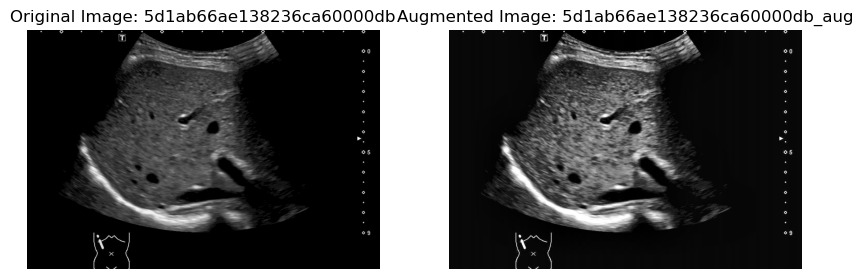

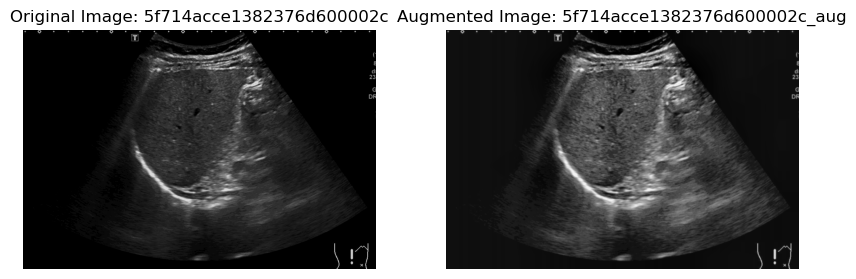

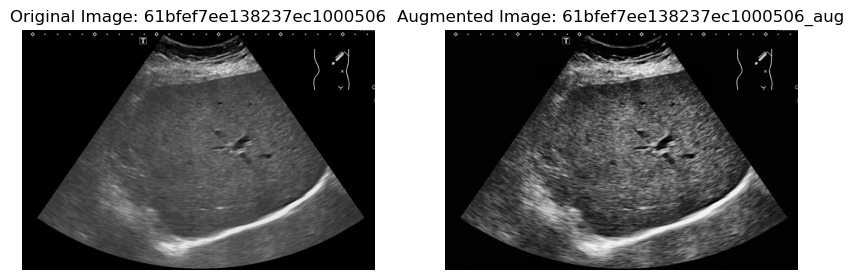

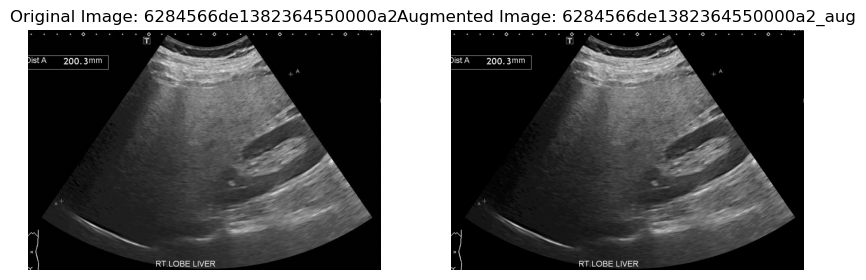

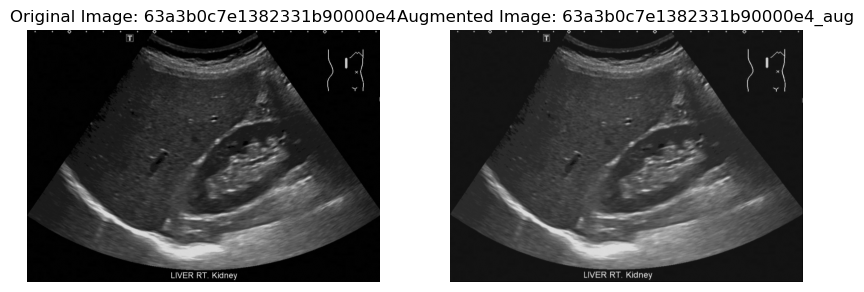

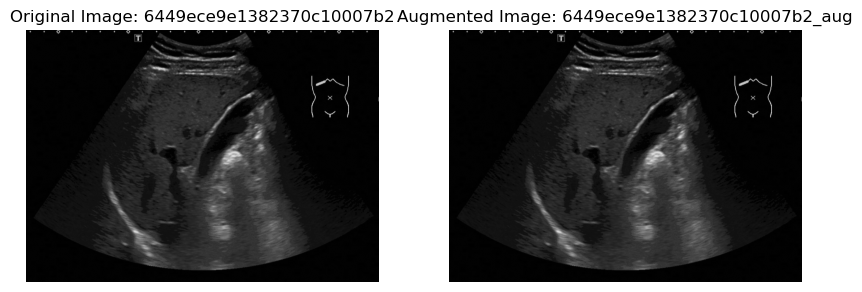

Number of augmented rows: 236
0


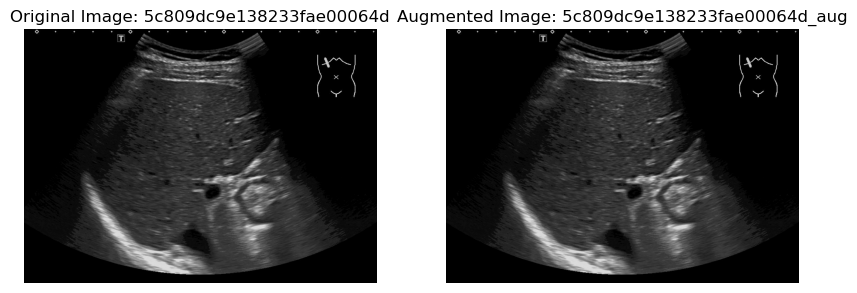

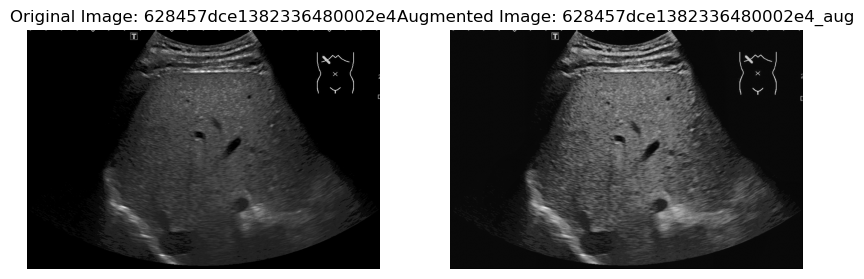

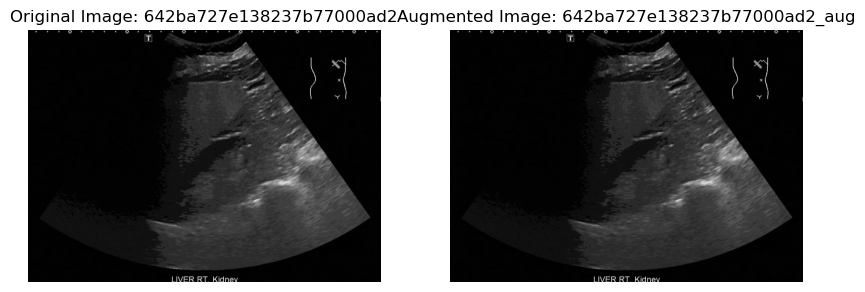

Number of augmented rows: 108
0


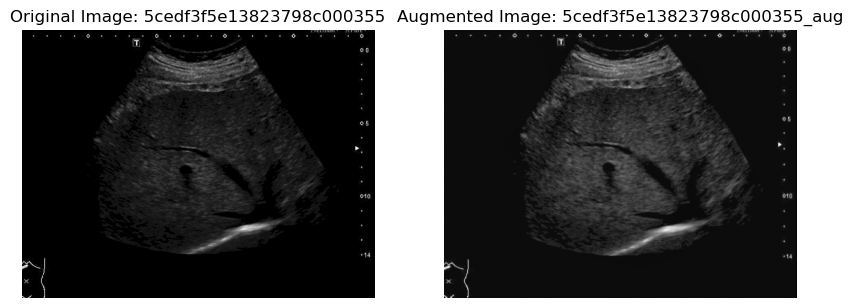

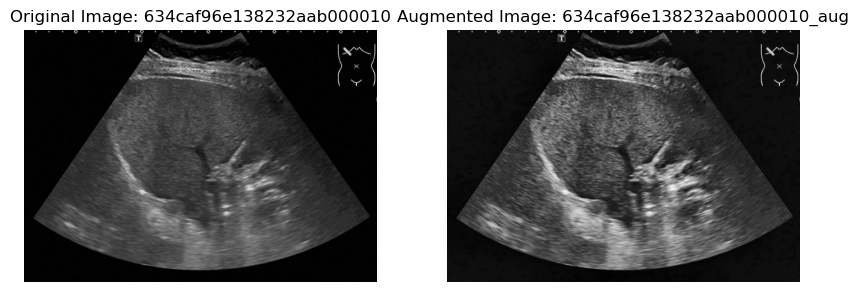

Number of augmented rows: 69
0


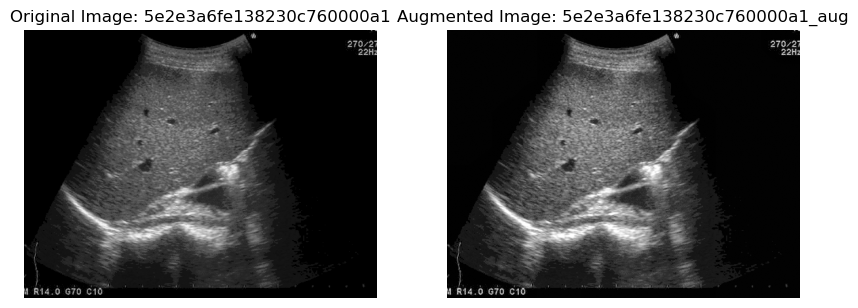

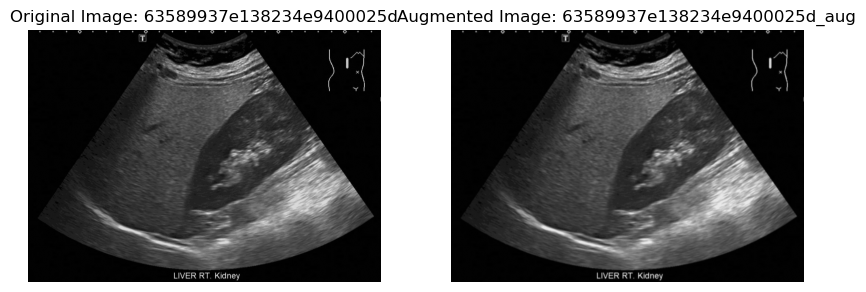

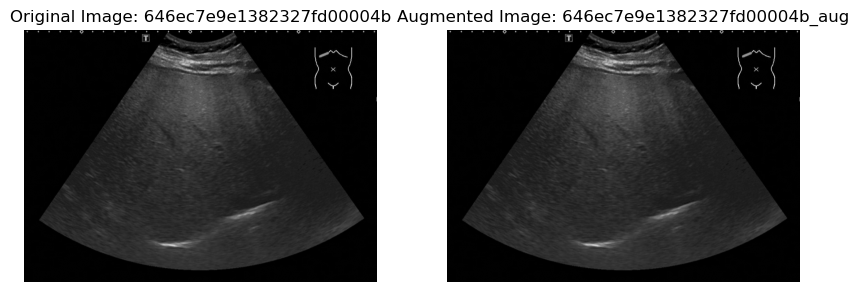

Number of augmented rows: 103
0


In [6]:
f1 = augmentation_function(df=f1)
f2 = augmentation_function(df=f2)
f3 = augmentation_function(df=f3)
f4 = augmentation_function(df=f4)

In [7]:
print(f"F0: {len(f0)}, F1: {len(f1)}, F2: {len(f2)}, F3: {len(f3)}, F4: {len(f4)}")

F0: 1256, F1: 472, F2: 216, F3: 138, F4: 206


In [8]:
train_df_augment = pd.concat([f0, f1, f2, f3, f4], ignore_index=True)
train_df_augment.to_csv("/project/ai901504-ai0004/501641_Big/week5/train_augment.csv", index=False)

In [9]:
train_df_augment

,subject,image_name,view,SWE fibrosis stage,TE(kPa),TE result
0,1,5c7e1166e138234adf000b5a,Intercostal,F2,3.4,F0
1,4,5cff0755e13823254900015b,Liver/RK,F0-1,4.8,F0
2,5,5d09abdce1382378f30003e5,Subcostal_hepatic_vein,F0-1,5.9,F0
3,5,5d09ac35e1382378f300040b,Liver/RK,F0-1,5.9,F0
4,9,5d1c0707e138230473000288,Subcostal_hepatic_vein,F0-1,4.4,F0
...,...,...,...,...,...,...
2283,684,64c1cf26e13823510a000261_aug,Subcostal_hepatic_vein,F0-1,46.0,F4
2284,684,64c1cf3fe1382359e300008c_aug,Liver/RK,F0-1,46.0,F4
2285,686,64c1eddfe13823510a00086f_aug,Liver/RK,F0-1,11.0,F4
2286,686,64c1edefe13823510a000875_aug,Intercostal,F0-1,11.0,F4


#### Preprocess

In [10]:
input_path = Path("/project/ai901504-ai0004/501641_Big/week5/dataset_2k")

In [18]:
apply_preprocessing(input_path, extract_roi_from_sonogram, "png")
# apply_preprocessing(input_path, histogram_equalization, "png")
apply_preprocessing(input_path, gamma_correction, "png")
# apply_preprocessing(input_path, distillation_transformation, "png")
apply_preprocessing(input_path, intensity_transformation, "png")
# apply_preprocessing(input_path, pseudocolor_image, "png")

Processing /project/ai901504-ai0004/501641_Big/week5/dataset_2k: 100%|██████████| 2735/2735 [02:40<00:00, 17.00it/s]
Processing /project/ai901504-ai0004/501641_Big/week5/dataset_2k: 100%|██████████| 2735/2735 [00:35<00:00, 77.29it/s]
Processing /project/ai901504-ai0004/501641_Big/week5/dataset_2k: 100%|██████████| 2735/2735 [00:53<00:00, 51.40it/s]


In [ ]:
folder_path = Path('/project/ai901504-ai0004/501641_Big/week5/dataset_2k')
num_files = len(list(folder_path.glob('*')))  # All files (not recursive)
print(f"Number of files: {num_files}")

Number of files: 2462


## Preprocess folder (14k)

In [ ]:
# rm -r /project/ai901504-ai0004/501641_Big/week5/dataset_14k
# mkdir  /project/ai901504-ai0004/501641_Big/week5/dataset_14k
# cp -r /project/ai901504-ai0004/kaggle_competition/week5/liver-fibrosis-severity-prediction/liver-lesion/* dataset_14k
# Run คำสั่ง rm -rf /project/ai901504-ai0004/501641_Big/week5/dataset_14k && mkdir /project/ai901504-ai0004/501641_Big/week5/dataset_14k && cp -r /project/ai901504-ai0004/kaggle_competition/week5/liver-fibrosis-severity-prediction/liver-lesion/* /project/ai901504-ai0004/501641_Big/week5/dataset_14k/

In [ ]:
input_path = Path("/project/ai901504-ai0004/501641_Big/week5/dataset_14k/images")

In [ ]:
apply_preprocessing(input_path, extract_roi_from_sonogram, "jpg")
apply_preprocessing(input_path, histogram_equalization, "jpg")
apply_preprocessing(input_path, distillation_transformation, "jpg")
apply_preprocessing(input_path, intensity_transformation, "jpg")
apply_preprocessing(input_path, pseudocolor_image, "jpg")

# Segmentation

# YOLO 2K

In [ ]:
# mkdir '/project/ai901504-ai0004/501641_Big/week5/dataset_te_yolo'
# make file dataset.yaml

In [ ]:
IMAGE_SOURCE_DIR = "/project/ai901504-ai0004/501641_Big/week5/dataset_2k"

# Destination root directory for the new YOLO dataset structure
OUTPUT_ROOT_DIR = '/project/ai901504-ai0004/501641_Big/week5/dataset_te_yolo'


'''ClassificationDataset/
├── data.yaml
├── train/
│   ├── class_A/
│   │   ├── image001.jpg
│   │   ├── image002.png
│   │   └── ...
│   ├── class_B/
│   │   ├── image101.jpg
│   │   └── ...
│   └── class_C/
│       ├── image201.jpg
│       └── ...
├── valid/
│   ├── class_A/
│   │   ├── image301.jpg
│   │   └── ...
│   ├── class_B/
│   │   ├── image401.jpg
│   │   └── ...
│   └── class_C/
│       ├── image501.jpg
│       └── ...'''

In [ ]:
f0 = train_df[train_df["TE result"] == "F0"]
f1 = train_df[train_df["TE result"] == "F1"]
f2 = train_df[train_df["TE result"] == "F2"]
f3 = train_df[train_df["TE result"] == "F3"]
f4 = train_df[train_df["TE result"] == "F4"]

print(f"F0: {len(f0)}, F1: {len(f1)}, F2: {len(f2)}, F3: {len(f3)}, F4: {len(f4)}")

In [ ]:
groups = [f0, f1, f2, f3, f4]
labels = ["F0", "F1", "F2", "F3", "F4"]
i = 0

for df in groups:
    file = df['image_name'].tolist()
    train, val = train_test_split(file, test_size=0.2, random_state=42)

    for file_name in train:
        src_path = os.path.join(IMAGE_SOURCE_DIR, file_name + '.png')
        dst_path = os.path.join(OUTPUT_ROOT_DIR, 'train', f'F{i}', file_name + '.png')
        shutil.copy(src_path, dst_path)
            
    for file_name in val:
        src_path = os.path.join(IMAGE_SOURCE_DIR, file_name + '.png')
        dst_path = os.path.join(OUTPUT_ROOT_DIR, 'val', f'F{i}', file_name + '.png')
        shutil.copy(src_path, dst_path)
    i += 1

# YOLO_14k

In [ ]:
IMAGE_SOURCE_DIR = "/project/ai901504-ai0004/501641_Big/week5/dataset_14k/images/"
ANNOTATION_SOURCE_DIR = "/project/ai901504-ai0004/501641_Big/week5/dataset_14k/annotations/"

# Destination root directory for the new YOLO dataset structure
OUTPUT_ROOT_DIR = '/project/ai901504-ai0004/501641_Big/week5/dataset_yolo'


# --- Create Output Directories ---
# output_images_train_dir = os.path.join(OUTPUT_ROOT_DIR, 'images', 'train')
# output_images_val_dir = os.path.join(OUTPUT_ROOT_DIR, 'images', 'val')
# output_labels_train_dir = os.path.join(OUTPUT_ROOT_DIR, 'labels', 'train')
# output_labels_val_dir = os.path.join(OUTPUT_ROOT_DIR, 'labels', 'val')

# # Ensure all necessary output directories exist
# os.makedirs(output_images_train_dir, exist_ok=True)
# os.makedirs(output_images_val_dir, exist_ok=True)
# os.makedirs(output_labels_train_dir, exist_ok=True)
# os.makedirs(output_labels_val_dir, exist_ok=True)

In [ ]:
all_annotation_files = os.listdir(ANNOTATION_SOURCE_DIR)
all_annotation_files = [f.replace(".txt", "") for f in all_annotation_files]

train, val = train_test_split(all_annotation_files, test_size=0.2, random_state=42)

for file_name in train:
    src_path = os.path.join(IMAGE_SOURCE_DIR, file_name + '.jpg')
    dst_path = os.path.join(OUTPUT_ROOT_DIR, 'images', 'train', file_name + '.jpg')
    shutil.copy(src_path, dst_path)
    
    src_path = os.path.join(ANNOTATION_SOURCE_DIR, file_name + '.txt')
    dst_path = os.path.join(OUTPUT_ROOT_DIR, 'labels', 'train', file_name + '.txt')
    shutil.copy(src_path, dst_path)
        
for file_name in val:
    src_path = os.path.join(IMAGE_SOURCE_DIR, file_name + '.jpg')
    dst_path = os.path.join(OUTPUT_ROOT_DIR, 'images', 'val', file_name + '.jpg')
    shutil.copy(src_path, dst_path)
    
    src_path = os.path.join(ANNOTATION_SOURCE_DIR, file_name + '.txt')
    dst_path = os.path.join(OUTPUT_ROOT_DIR, 'labels', 'val', file_name + '.txt')
    shutil.copy(src_path, dst_path)
        

# Regrssor_format (2k)

In [2]:
train_df = pd.read_csv("/project/ai901504-ai0004/kaggle_competition/week5/liver-fibrosis-severity-prediction/train.csv")
train_df['SWE fibrosis stage'] = train_df['SWE fibrosis stage'].replace('F2 ', 'F2')
train_df['SWE fibrosis stage'] = train_df['SWE fibrosis stage'].replace('-', 'F2')

In [3]:
train_df.columns

Index(['subject', 'image_name', 'view', 'SWE fibrosis stage', 'TE(kPa)',
       'TE result'],
      dtype='object')

In [4]:
train_df['SWE fibrosis stage'].value_counts()

SWE fibrosis stage
F0-1    1475
F2       195
-         46
F4        36
F3        20
Name: count, dtype: int64

In [5]:
num_cols = ['TE(kPa)']

# Group by fibrosis stage
agg_df = train_df.groupby('SWE fibrosis stage')[num_cols].agg(['mean', 'median', 'max', 'min', 'std'])

agg_df.columns = ['_'.join(col).strip() for col in agg_df.columns.values]

train_df = train_df.merge(agg_df, how='left', left_on='SWE fibrosis stage', right_index=True)

In [6]:
cross_tab = train_df.groupby(['SWE fibrosis stage', 'TE result']).size().unstack(fill_value=0)
cross_tab_percent = cross_tab.div(cross_tab.sum(axis=1), axis=0)
print(cross_tab_percent)

TE result                 F0        F1        F2        F3        F4
SWE fibrosis stage                                                  
-                   0.369565  0.195652  0.108696  0.043478  0.282609
F0-1                0.806102  0.120000  0.033220  0.021695  0.018983
F2                  0.246154  0.200000  0.241026  0.148718  0.164103
F3                  0.000000  0.000000  0.000000  0.150000  0.850000
F4                  0.055556  0.305556  0.194444  0.083333  0.361111


In [7]:
# Step 1: Rename columns to make them clear
cross_tab_percent.columns = [f'TE_result_pct_{col}' for col in cross_tab_percent.columns]

# Step 2: Merge percentages back into train_df
train_df = train_df.merge(cross_tab_percent, how='left', left_on='SWE fibrosis stage', right_index=True)

In [8]:
train_df.head()

,subject,image_name,view,SWE fibrosis stage,TE(kPa),TE result,TE(kPa)_mean,TE(kPa)_median,TE(kPa)_max,TE(kPa)_min,TE(kPa)_std,TE_result_pct_F0,TE_result_pct_F1,TE_result_pct_F2,TE_result_pct_F3,TE_result_pct_F4
0,1,5c7e1166e138234adf000b5a,Intercostal,-,3.4,F0,8.495652,6.7,16.6,3.3,4.436112,0.369565,0.195652,0.108696,0.043478,0.282609
1,2,5c809dc9e138233fae00064d,Intercostal,-,8.5,F2,8.495652,6.7,16.6,3.3,4.436112,0.369565,0.195652,0.108696,0.043478,0.282609
2,3,5cedf3f5e13823798c000355,Subcostal_hepatic_vein,F2,9.4,F3,8.242564,7.6,27.6,3.3,3.962307,0.246154,0.200000,0.241026,0.148718,0.164103
3,3,5cedf408e13823798c00035e,Intercostal,F2,9.4,F3,8.242564,7.6,27.6,3.3,3.962307,0.246154,0.200000,0.241026,0.148718,0.164103
4,3,5cedf40ce13823798c000364,Liver/RK,F2,9.4,F3,8.242564,7.6,27.6,3.3,3.962307,0.246154,0.200000,0.241026,0.148718,0.164103


In [9]:
test_df = pd.read_csv("/project/ai901504-ai0004/kaggle_competition/week5/liver-fibrosis-severity-prediction/test_submission.csv")

In [10]:
test_df['SWE fibrosis stage'] = test_df['SWE fibrosis stage'].replace('F2 ', 'F2')
test_df['SWE fibrosis stage'] = test_df['SWE fibrosis stage'].replace('F4 ', 'F4')
train_df['SWE fibrosis stage'] = train_df['SWE fibrosis stage'].replace('-', 'F2')
test_df['SWE fibrosis stage'].value_counts()

SWE fibrosis stage
F0-1    377
F2       30
-        13
F4       11
F3        2
Name: count, dtype: int64

In [11]:
test_df = test_df.merge(agg_df, how='left', left_on='SWE fibrosis stage', right_index=True)
test_df = test_df.merge(cross_tab_percent, how='left', left_on='SWE fibrosis stage', right_index=True)

In [12]:
test_df.head()

,image_name,view,SWE fibrosis stage,TE(kPa),TE(kPa)_mean,TE(kPa)_median,TE(kPa)_max,TE(kPa)_min,TE(kPa)_std,TE_result_pct_F0,TE_result_pct_F1,TE_result_pct_F2,TE_result_pct_F3,TE_result_pct_F4
0,5c7de4d6e138234adf00044d,Intercostal,-,8.8,8.495652,6.7,16.6,3.3,4.436112,0.369565,0.195652,0.108696,0.043478,0.282609
1,5d118de2e138237034000368,Liver/RK,F0-1,4.3,5.043525,4.6,46.0,2.4,2.498163,0.806102,0.120000,0.033220,0.021695,0.018983
2,5d1ae0b9e13823585300002f,Intercostal,F0-1,7.5,5.043525,4.6,46.0,2.4,2.498163,0.806102,0.120000,0.033220,0.021695,0.018983
3,5d1ae0c2e138236ca60005b9,Liver/RK,F0-1,NaN,5.043525,4.6,46.0,2.4,2.498163,0.806102,0.120000,0.033220,0.021695,0.018983
4,5d1ae0c4e138236ca60005bd,Subcostal_hepatic_vein,F0-1,NaN,5.043525,4.6,46.0,2.4,2.498163,0.806102,0.120000,0.033220,0.021695,0.018983


In [13]:
train_df.to_csv("regressor_train.csv",index = False)
test_df.to_csv("regressor_test.csv",index = False)

# Not use

#### Preprocesss folder (for annotation yolo)

In [ ]:
# rm -r /project/ai901504-ai0004/501641_Big/week5/dataset_yolo_preprocess
# mkdir /project/ai901504-ai0004/501641_Big/week5/dataset_yolo_preprocess
# cp -r /project/ai901504-ai0004/501641_Big/week5/dataset_yolo /project/ai901504-ai0004/501641_Big/week5/dataset_yolo_preprocess
# Run คำสั่ง rm -rf /project/ai901504-ai0004/501641_Big/week5/dataset_yolo_preprocess && mkdir /project/ai901504-ai0004/501641_Big/week5/dataset_yolo_preprocess && cp -r /project/ai901504-ai0004/501641_Big/week5/dataset_yolo/* /project/ai901504-ai0004/501641_Big/week5/dataset_yolo_preprocess/

In [ ]:
input_path_train = Path("/project/ai901504-ai0004/501641_Big/week5/dataset_yolo_preprocess/images/train")
input_path_eval = Path("/project/ai901504-ai0004/501641_Big/week5/dataset_yolo_preprocess/images/val")

In [ ]:
apply_preprocessing(input_path_train, extract_roi_from_sonogram, "jpg")
apply_preprocessing(input_path_train, histogram_equalization, "jpg")
apply_preprocessing(input_path_train, distillation_transformation, "jpg")
apply_preprocessing(input_path_train, intensity_transformation, "jpg")
# apply_preprocessing(input_path_train, pseudocolor_image, "jpg")

apply_preprocessing(input_path_eval, extract_roi_from_sonogram, "jpg")
apply_preprocessing(input_path_eval, histogram_equalization, "jpg")
apply_preprocessing(input_path_eval, distillation_transformation, "jpg")
apply_preprocessing(input_path_eval, intensity_transformation, "jpg")
# apply_preprocessing(input_path_eval, pseudocolor_image, "jpg")

#### Preprocess folder (for classification yolo)

In [ ]:
# rm -r /project/ai901504-ai0004/501641_Big/week5/dataset_te_yolo_preprocess
# mkdir /project/ai901504-ai0004/501641_Big/week5/dataset_te_yolo_preprocess
# cp -r /project/ai901504-ai0004/501641_Big/week5/dataset_te_yolo /project/ai901504-ai0004/501641_Big/week5/dataset_te_yolo_preprocess
# Run คำสั่ง rm -rf /project/ai901504-ai0004/501641_Big/week5/dataset_te_yolo_preprocess && mkdir /project/ai901504-ai0004/501641_Big/week5/dataset_te_yolo_preprocess && cp -r /project/ai901504-ai0004/501641_Big/week5/dataset_te_yolo/* /project/ai901504-ai0004/501641_Big/week5/dataset_te_yolo_preprocess/

In [ ]:
input_path_train = Path(f"/project/ai901504-ai0004/501641_Big/week5/dataset_te_yolo_preprocess/train/F{i}")
input_path_eval = Path(f"/project/ai901504-ai0004/501641_Big/week5/dataset_te_yolo_preprocess/val/F{i}")

In [ ]:
i = 0
for i in range(5):
    input_path_train = Path(f"/project/ai901504-ai0004/501641_Big/week5/dataset_te_yolo_preprocess/train/F{i}")
    input_path_eval = Path(f"/project/ai901504-ai0004/501641_Big/week5/dataset_te_yolo_preprocess/val/F{i}")
    apply_preprocessing(input_path_train, extract_roi_from_sonogram, "png")
    # apply_preprocessing(input_path_train, histogram_equalization, "png")
    apply_preprocessing(input_path_train, distillation_transformation, "png")
    apply_preprocessing(input_path_train, intensity_transformation, "png")
    # apply_preprocessing(input_path_train, pseudocolor_image, "png")
    
    apply_preprocessing(input_path_eval, extract_roi_from_sonogram, "png")
    # apply_preprocessing(input_path_eval, histogram_equalization, "png")
    apply_preprocessing(input_path_eval, distillation_transformation, "png")
    apply_preprocessing(input_path_eval, intensity_transformation, "png")
    # apply_preprocessing(input_path_eval, pseudocolor_image, "png")